# HOMEWORK 1

Done by: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/ComputerVision-PBY_HW1

In [1]:
# Silent installation or update

# Clean cache
!python3 -m pip cache purge -q

# Force updating
package_update = [
    "pip",
    "scikit-learn",
    "pandas",
]

for package_name in package_update:
    !bash -c "python3 -m pip install -U '{package_name}' -q"

# Install missing packages
package_array = [
    "jinja2",
    "ipywidgets",
    "nbformat",
    "numpy",
    "matplotlib",
    "opencv-python",
]

for package_name in package_array:
    !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"

# Note. To upload big files to GitHub, execute the next command in the terminal
# 1. brew install git-lfs
# 2. git lfs install
# 3.1. git lfs track "*.safetensors"
# 3.2. git lfs track "*.bin"

In [2]:
# Synchronization with remote source

import shutil
from pathlib import Path

# Input images
hm_version = 1

# Solution
git_project_url = f"https://github.com/BogdanPinchuk/ComputerVision-PBY_HW{hm_version}.git"
main_file_name = f"Bohdan_Pinchuk_CV_HW{hm_version}.ipynb"

# upload all files
current_path = !pwd
current_path = current_path[0]
parent_path = !dirname "$current_path"
parent_path = parent_path[0]
temp_path = f"{parent_path}/temp"

# Clone images
!rm -rf "$temp_path"
!git clone "$git_project_url" "$temp_path"

source = Path(temp_path)
destination = Path(current_path)
exclude = {main_file_name, ".git", ".idea"}

for item in source.iterdir():
    if item.name in exclude:
        continue

    target = destination / item.name
    if item.is_dir():
        shutil.copytree(item, target, dirs_exist_ok=True)
    else:
        shutil.copy2(item, target)

# Clean temp folder
!rm -rf "$temp_path"

Once your environment is set up (see `homework.md` for the three tracks — plain venv, conda, or Colab), this notebook is where you verify it: **complete the blank lines and run every cell top to bottom with no errors.**

Run Jupyter from inside `lesson_1/` so the relative `data/` paths resolve, and select your course kernel (e.g. *Python (cv)*) if prompted.

You will build two collages:
1. a 2×2 collage of the image with its colour channels reordered (RGB, RBG, GRB, BGR);
2. a collage of the image flipped horizontally and vertically.

In [25]:
# Load data

import cv2
import apps.reporter as rpt
from pathlib import Path

# Input data
file_name = "resources/images/kodim21.png"

# Solution
file_path = Path(file_name)

# Load an image (you can freely choose any image you like)
if file_path.exists():
    img_bgr = cv2.imread(file_path)
else:
    raise FileNotFoundError("File doesn't exist!")

# Convert it to RGB
if img_bgr is None:
    raise ValueError('Incorrect input data "img_bgr"!')
else:
    # Variant 1: using CV
    # img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Variant 2: reversed slicing => [:, :, ::-1]
    img_rgb = img_bgr[..., ::-1]

rp = rpt.Reporter()
rp.add_item("(rows, cols, channels)", str(img_rgb.shape))

# Print results
rp.print_pd_report("Image shape")


Attribute,Result
"(rows, cols, channels)","(512, 768, 3)"


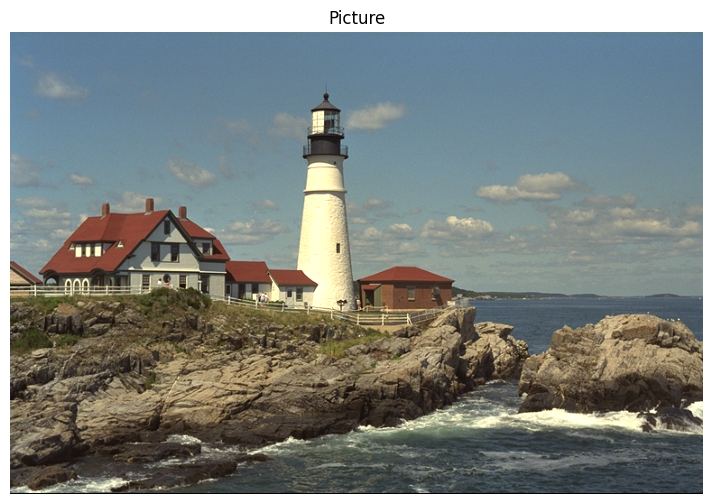

In [26]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data = img_rgb
# Global config of the picture size
# plt.rcParams['figure.figsize'] = [15, 10]

# Solution
_, ax = plt.subplots(figsize=(9, 6))

ax.imshow(data)
ax.axis(False)

# Plot it
plt.title("Picture")
plt.show()


Let's make the channel-reorder collage.

In [27]:
# Collage V1

import cv2
import numpy as np
import apps.reporter as rpt

# Input data

# Solution
if img_bgr is None:
    raise ValueError('Incorrect input data "img_bgr"!')
else:
    # Split the image into the three colour channels
    blue, green, red = cv2.split(img_bgr)

    # Compose the image in the RGB colour space
    img1 = cv2.merge([red, green, blue])
    # Compose the image in the RBG colour space
    img2 = cv2.merge([red, blue, green])
    # Compose the image in the GRB colour space
    img3 = cv2.merge([green, red, blue])
    # Compose the image in the BGR colour space
    img4 = cv2.merge([blue, green, red])

    # Create the collage
    out1 = np.hstack([img1, img2])
    out2 = np.hstack([img3, img4])
    out = np.vstack([out1, out2])

rp = rpt.Reporter()
rp.add_item("(rows, cols, channels)", str(out.shape))

# Print results
rp.print_pd_report("Collage shape")


Attribute,Result
"(rows, cols, channels)","(1024, 1536, 3)"


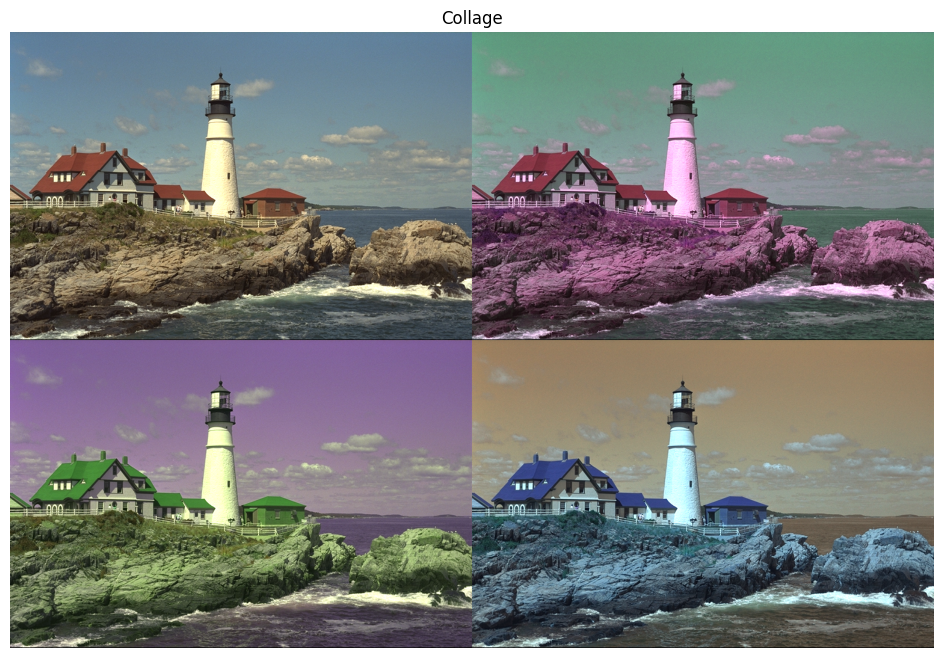

In [28]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data = out

# Solution
_, ax = plt.subplots(figsize=(12, 8))

ax.imshow(data)
ax.axis(False)

# Plot it
plt.title("Collage")
plt.show()


In [29]:
# Collage V2

import cv2
import numpy as np
import apps.reporter as rpt

# Input data

# Solution
if img_bgr is None:
    raise ValueError('Incorrect input data "img_bgr"!')
else:
    # Split the image into the three colour channels
    blue, green, red = cv2.split(img_bgr)

    # Compose the image in the RGB colour space
    img1 = cv2.merge([red, green, blue])
    # Compose the image in the RBG colour space
    img2 = cv2.merge([red, blue, green])
    # Compose the image in the GRB colour space
    img3 = cv2.merge([green, red, blue])
    # Compose the image in the BGR colour space
    img4 = cv2.merge([blue, green, red])
    # Compose the image in the GBR colour space
    img5 = cv2.merge([green, blue, red])
    # Compose the image in the BRG colour space
    img6 = cv2.merge([blue, red, green])

    # Create the collage
    out1 = np.hstack([img1, img2])
    out2 = np.hstack([img3, img4])
    out3 = np.hstack([img5, img6])
    out_v2 = np.vstack([out1, out2, out3])

rp = rpt.Reporter()
rp.add_item("(rows, cols, channels)", str(out_v2.shape))

# Print results
rp.print_pd_report("Collage shape V2")


Attribute,Result
"(rows, cols, channels)","(1536, 1536, 3)"


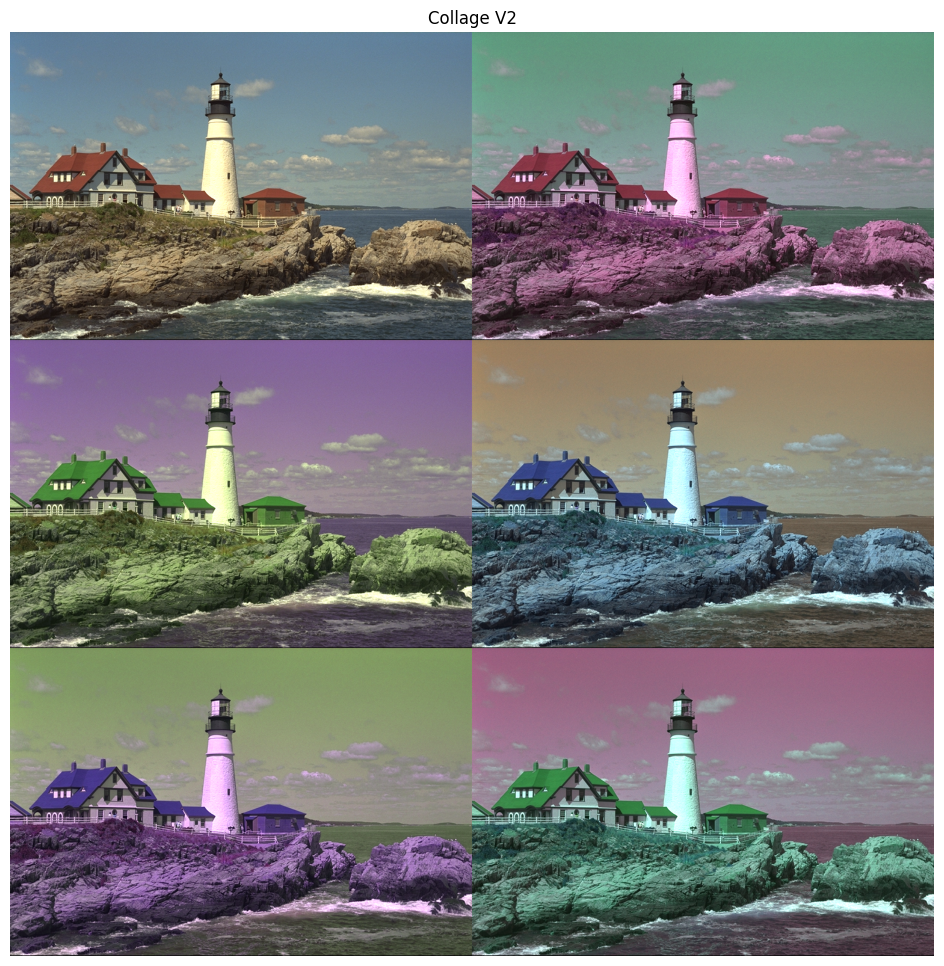

In [30]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data = out_v2

# Solution
_, ax = plt.subplots(figsize=(12, 12))

ax.imshow(data)
ax.axis(False)

# Plot it
plt.title("Collage V2")
plt.show()


Now make a simple geometric collage: flip the image both horizontally and vertically to reproduce the layout below.

![example collage](resources/images/example.jpg "Expected result")

You can flip the arrays by slicing, or use the numpy helpers [fliplr](https://numpy.org/doc/stable/reference/generated/numpy.fliplr.html) and [flipud](https://numpy.org/doc/stable/reference/generated/numpy.flipud.html) ;-).

In [36]:
# Load data

import cv2
import apps.reporter as rpt
from pathlib import Path

# Input data
file_name2 = "resources/images/What-Is-Computer-Vision_An-Introduction.jpg"

# Solution
file_path2 = Path(file_name2)

# Load an image (you can freely choose any image you like)
if file_path2.exists():
    img_bgr2 = cv2.imread(file_path2)
else:
    raise FileNotFoundError("File doesn't exist!")

# Convert it to RGB
if img_bgr2 is None:
    raise ValueError('Incorrect input data "img_bgr_2"!')
else:
    # Convert it to RGB
    img_rgb2 = cv2.cvtColor(img_bgr2, cv2.COLOR_BGR2RGB)

rp = rpt.Reporter()
rp.add_item("(rows, cols, channels)", str(img_rgb2.shape))

# Print results
rp.print_pd_report("Image shape")


Attribute,Result
"(rows, cols, channels)","(486, 821, 3)"


In [43]:
# Flip-collage

import numpy as np
import apps.reporter as rpt

# Input data

# Solution
if img_rgb2 is None:
    raise ValueError('Incorrect input data "img_rgb_2"!')
else:
    # Make a collage
    img1 = img_rgb2
    img2 = np.fliplr(img1)

    out1 = np.hstack([img1, img2])
    out2 = np.flipud(out1)
    out_v3 = np.vstack([out1, out2])

rp = rpt.Reporter()
rp.add_item("(rows, cols, channels)", str(out_v3.shape))

# Print results
rp.print_pd_report("Collage shape")


Attribute,Result
"(rows, cols, channels)","(972, 1642, 3)"


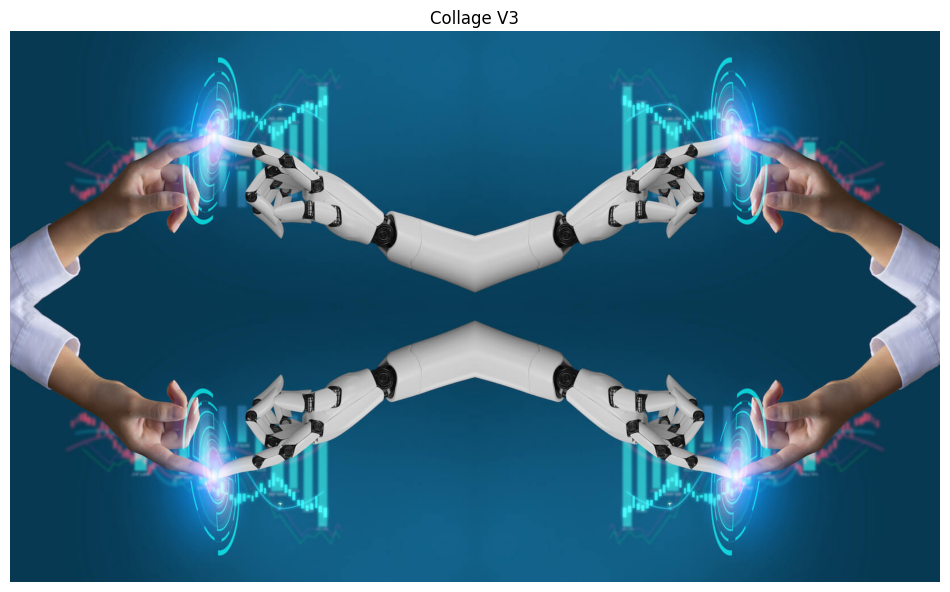

In [45]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data = out_v3

# Solution
_, ax = plt.subplots(figsize=(12, 8))

ax.imshow(data)
ax.axis(False)

# Plot it
plt.title("Collage V3")
plt.show()
